In [1]:
# Run once — comment out after first run
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
!pip install --upgrade --force-reinstall sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Paths ─────────────────────────────────────────────────────────
DATA_PATH    = "cleaned_labeled_dataset.csv"   # update path if needed
OUTPUT_DIR   = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


In [4]:
import pandas as pd
df = pd.read_csv('/content/cleaned_labeled_dataset (1).csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nSample rows:")
df[["text_clean", "label"]].head()

Shape: (10296, 4)

Columns: ['post_id', 'text_clean', 'label', 'word_count']

Label distribution:
label
ptsd          2574
depression    2574
normal        2574
anxiety       2574
Name: count, dtype: int64

Sample rows:


,text_clean,label
0,fck get fckinf break holy sht okay well every ...,ptsd
1,know fact never commit suicide mostly emotiona...,depression
2,alice url raising hell europe '70s '80s day ga...,normal
3,father alcoholic year mom deal entire time lat...,ptsd
4,suffering depression anxiety issue past month ...,depression


In [5]:
from sklearn.preprocessing import LabelEncoder

# Drop any rows with missing text
df = df.dropna(subset=["text_clean"]).reset_index(drop=True)

# Encode string labels → integers
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} → {cls}")

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)

Label mapping:
  0 → anxiety
  1 → depression
  2 → normal
  3 → ptsd


In [6]:
from sklearn.model_selection import train_test_split

X = df["text_clean"].values
y = df["label_enc"].values

# First split off the test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Then split train/val from the remaining 80% (val = 10% of total → 12.5% of 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,          # 0.125 × 0.80 = 0.10 of total
    random_state=SEED,
    stratify=y_train_val
)

print(f"Train : {len(X_train):,} samples")
print(f"Val   : {len(X_val):,} samples")
print(f"Test  : {len(X_test):,} samples")

# Save y_test for Member C
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)
print("\ny_test saved.")

Train : 7,206 samples
Val   : 1,030 samples
Test  : 2,060 samples

y_test saved.


In [7]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30_000,
        ngram_range=(1, 2),       # unigrams + bigrams
        sublinear_tf=True,        # log(1+tf) — helps with long docs
        min_df=2,                 # ignore very rare terms
    )),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",  # handles any residual imbalance
        max_iter=2000,
        random_state=SEED,
    )),
])

svm_pipeline.fit(X_train, y_train)
print("SVM training complete.")

SVM training complete.


In [8]:
y_val_pred_svm = svm_pipeline.predict(X_val)

print("=== SVM — Validation Set ===")
print(classification_report(y_val, y_val_pred_svm, target_names=CLASS_NAMES))

=== SVM — Validation Set ===
              precision    recall  f1-score   support

     anxiety       0.82      0.90      0.86       258
  depression       0.85      0.82      0.84       257
      normal       0.88      0.86      0.87       258
        ptsd       0.75      0.71      0.73       257

    accuracy                           0.82      1030
   macro avg       0.82      0.82      0.82      1030
weighted avg       0.82      0.82      0.82      1030



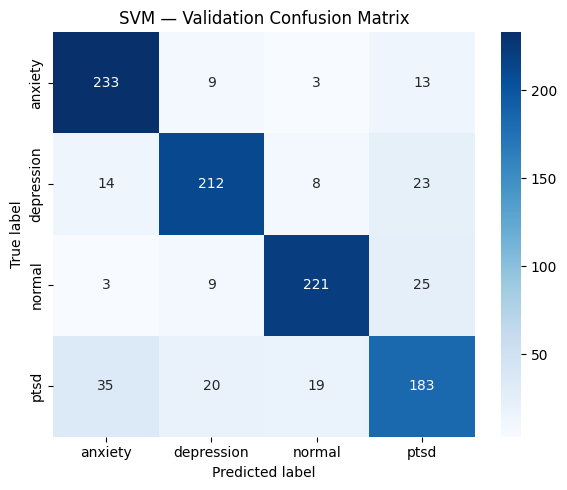

In [9]:
cm_svm_val = confusion_matrix(y_val, y_val_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm_val, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title("SVM — Validation Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "svm_val_confusion_matrix.png"), dpi=150)
plt.show()

In [10]:
y_pred_svm = svm_pipeline.predict(X_test)
np.save(os.path.join(OUTPUT_DIR, "y_pred_svm.npy"), y_pred_svm)

print("=== SVM — Test Set ===")
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES))
print("y_pred_svm.npy saved.")

=== SVM — Test Set ===
              precision    recall  f1-score   support

     anxiety       0.83      0.87      0.85       515
  depression       0.85      0.81      0.83       515
      normal       0.83      0.88      0.85       515
        ptsd       0.78      0.73      0.75       515

    accuracy                           0.82      2060
   macro avg       0.82      0.82      0.82      2060
weighted avg       0.82      0.82      0.82      2060

y_pred_svm.npy saved.


In [11]:
BERT_MODEL_NAME = "bert-base-uncased"
MAX_LEN         = 128    # covers ~95% of posts based on Member A word counts
BATCH_SIZE      = 16     # use 8 if GPU runs out of memory

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


In [12]:
def tokenize_texts(texts):
    """Return a dict of tensors ready for BERT."""
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

print("Tokenizing train set...")
train_enc = tokenize_texts(X_train)
print("Tokenizing val set...")
val_enc   = tokenize_texts(X_val)
print("Tokenizing test set...")
test_enc  = tokenize_texts(X_test)
print("Done.")

Tokenizing train set...
Tokenizing val set...
Tokenizing test set...
Done.


In [13]:
class MentalHealthDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = MentalHealthDataset(train_enc, y_train)
val_dataset   = MentalHealthDataset(val_enc,   y_val)
test_dataset  = MentalHealthDataset(test_enc,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 451
Val batches   : 65
Test batches  : 129


In [14]:
model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
)
model.to(DEVICE)
print("BERT model loaded and moved to", DEVICE)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded and moved to cuda


In [15]:
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1   # 10% of total steps used for warmup

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

Total steps  : 1804
Warmup steps : 180


In [16]:
def evaluate(model, loader):
    """Return avg loss and accuracy on a DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch["labels"]).sum().item()
            total   += batch["labels"].size(0)
    return total_loss / len(loader), correct / total


best_val_loss = float("inf")
best_model_path = os.path.join(OUTPUT_DIR, "bert_best_checkpoint")

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, 1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        if step % 50 == 0:
            print(f"  Epoch {epoch} | Step {step}/{len(train_loader)} "
                  f"| Avg loss: {running_loss/step:.4f}")

    train_loss_avg = running_loss / len(train_loader)

    # ── Validate ─────────────────────────────────────────────────
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss_avg)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS} — "
          f"Train Loss: {train_loss_avg:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc*100:.2f}%")

    # ── Save best checkpoint ──────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"  ✓ New best model saved (val_loss={val_loss:.4f})")

    print()

print("Training complete.")

  Epoch 1 | Step 50/451 | Avg loss: 1.3612
  Epoch 1 | Step 100/451 | Avg loss: 1.3066
  Epoch 1 | Step 150/451 | Avg loss: 1.2159
  Epoch 1 | Step 200/451 | Avg loss: 1.1288
  Epoch 1 | Step 250/451 | Avg loss: 1.0423
  Epoch 1 | Step 300/451 | Avg loss: 0.9743
  Epoch 1 | Step 350/451 | Avg loss: 0.9153
  Epoch 1 | Step 400/451 | Avg loss: 0.8727
  Epoch 1 | Step 450/451 | Avg loss: 0.8377

Epoch 1/4 — Train Loss: 0.8366 | Val Loss: 0.5077 | Val Acc: 82.23%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val_loss=0.5077)

  Epoch 2 | Step 50/451 | Avg loss: 0.4355
  Epoch 2 | Step 100/451 | Avg loss: 0.4421
  Epoch 2 | Step 150/451 | Avg loss: 0.4265
  Epoch 2 | Step 200/451 | Avg loss: 0.4297
  Epoch 2 | Step 250/451 | Avg loss: 0.4270
  Epoch 2 | Step 300/451 | Avg loss: 0.4205
  Epoch 2 | Step 350/451 | Avg loss: 0.4107
  Epoch 2 | Step 400/451 | Avg loss: 0.4121
  Epoch 2 | Step 450/451 | Avg loss: 0.4083

Epoch 2/4 — Train Loss: 0.4079 | Val Loss: 0.4413 | Val Acc: 84.27%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val_loss=0.4413)

  Epoch 3 | Step 50/451 | Avg loss: 0.3000
  Epoch 3 | Step 100/451 | Avg loss: 0.2930
  Epoch 3 | Step 150/451 | Avg loss: 0.2882
  Epoch 3 | Step 200/451 | Avg loss: 0.2779
  Epoch 3 | Step 250/451 | Avg loss: 0.2733
  Epoch 3 | Step 300/451 | Avg loss: 0.2645
  Epoch 3 | Step 350/451 | Avg loss: 0.2645
  Epoch 3 | Step 400/451 | Avg loss: 0.2673
  Epoch 3 | Step 450/451 | Avg loss: 0.2592

Epoch 3/4 — Train Loss: 0.2587 | Val Loss: 0.4582 | Val Acc: 86.99%

  Epoch 4 | Step 50/451 | Avg loss: 0.1626
  Epoch 4 | Step 100/451 | Avg loss: 0.1599
  Epoch 4 | Step 150/451 | Avg loss: 0.1598
  Epoch 4 | Step 200/451 | Avg loss: 0.1666
  Epoch 4 | Step 250/451 | Avg loss: 0.1676
  Epoch 4 | Step 300/451 | Avg loss: 0.1661
  Epoch 4 | Step 350/451 | Avg loss: 0.1619
  Epoch 4 | Step 400/451 | Avg loss: 0.1586
  Epoch 4 | Step 450/451 | Avg loss: 0.1576

Epoch 4/4 — Train Loss: 0.1579 | Val Loss: 0.5134 | Val Acc: 86.50%

Training complete.


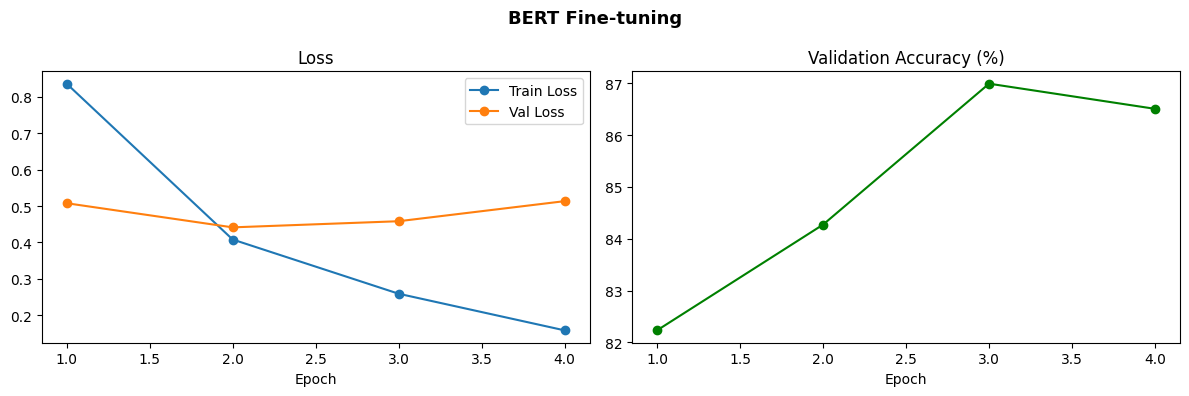

In [17]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("BERT Fine-tuning", fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   marker="o", label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, [a * 100 for a in history["val_acc"]], marker="o", color="green")
axes[1].set_title("Validation Accuracy (%)")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bert_training_curves.png"), dpi=150)
plt.show()

In [18]:
# Load the best saved model
best_model = BertForSequenceClassification.from_pretrained(best_model_path)
best_model.to(DEVICE)

val_loss, val_acc = evaluate(best_model, val_loader)
print(f"Best checkpoint — Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best checkpoint — Val Loss: 0.4413 | Val Acc: 84.27%


In [19]:
# Detailed val classification report
def get_predictions(model, loader):
    """Return concatenated true labels and predicted labels from a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").to(DEVICE)
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = best_model(**batch).logits
            preds  = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_val_true, y_val_pred_bert = get_predictions(best_model, val_loader)
print("=== BERT — Validation Set ===")
print(classification_report(y_val_true, y_val_pred_bert, target_names=CLASS_NAMES))

=== BERT — Validation Set ===
              precision    recall  f1-score   support

     anxiety       0.85      0.86      0.85       258
  depression       0.80      0.90      0.85       257
      normal       0.94      0.84      0.89       258
        ptsd       0.80      0.77      0.78       257

    accuracy                           0.84      1030
   macro avg       0.85      0.84      0.84      1030
weighted avg       0.85      0.84      0.84      1030



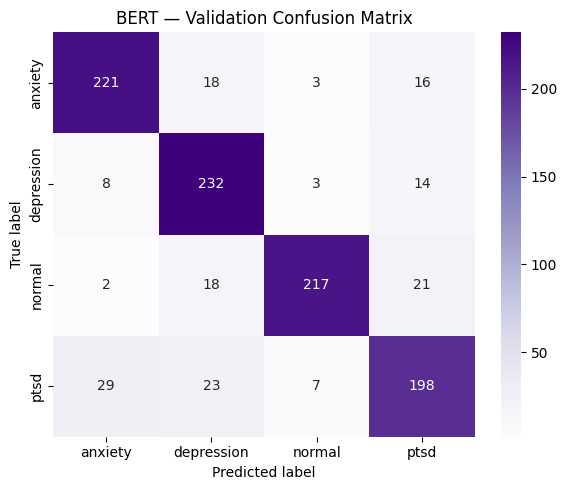

In [20]:
cm_bert_val = confusion_matrix(y_val_true, y_val_pred_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bert_val, annot=True, fmt="d", cmap="Purples",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title("BERT — Validation Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bert_val_confusion_matrix.png"), dpi=150)
plt.show()

In [21]:
y_test_true, y_pred_bert = get_predictions(best_model, test_loader)

np.save(os.path.join(OUTPUT_DIR, "y_pred_bert.npy"), y_pred_bert)

print("=== BERT — Test Set ===")
print(classification_report(y_test_true, y_pred_bert, target_names=CLASS_NAMES))
print("y_pred_bert.npy saved.")

=== BERT — Test Set ===
              precision    recall  f1-score   support

     anxiety       0.90      0.87      0.88       515
  depression       0.80      0.89      0.84       515
      normal       0.92      0.86      0.89       515
        ptsd       0.82      0.82      0.82       515

    accuracy                           0.86      2060
   macro avg       0.86      0.86      0.86      2060
weighted avg       0.86      0.86      0.86      2060

y_pred_bert.npy saved.


In [22]:
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "BERT (fine-tuned)"],
    "Val Accuracy": [
        round(accuracy_score(y_val, y_val_pred_svm), 4),
        round(accuracy_score(y_val_true, y_val_pred_bert), 4),
    ],
    "Val F1 (macro)": [
        round(f1_score(y_val, y_val_pred_svm, average="macro"), 4),
        round(f1_score(y_val_true, y_val_pred_bert, average="macro"), 4),
    ],
})

print(results.to_string(index=False))
results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_val.csv"), index=False)

            Model  Val Accuracy  Val F1 (macro)
     TF-IDF + SVM        0.8243          0.8233
BERT (fine-tuned)        0.8427          0.8430
